In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Windows 기본 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

#파일을 DataFrame으로 생성하고 객체 할당 
train_df=pd.read_csv(r'C:\Users\user\ESAA_YB\미니프로젝트1\movies_train.csv')


# **1.데이터 확인** 

In [3]:
train_df.head(5)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [4]:
train_df.tail(5)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
595,해무,(주)NEW,드라마,2014-08-13,111,청소년 관람불가,심성보,3833.0,1,510,7,1475091
596,파파로티,(주)쇼박스,드라마,2013-03-14,127,15세 관람가,윤종찬,496061.0,1,286,6,1716438
597,살인의 강,(주)마운틴픽쳐스,공포,2010-09-30,99,청소년 관람불가,김대현,NaN,0,123,4,2475
598,악의 연대기,CJ 엔터테인먼트,느와르,2015-05-14,102,15세 관람가,백운학,NaN,0,431,4,2192525
599,베를린,CJ 엔터테인먼트,액션,2013-01-30,120,15세 관람가,류승완,NaN,0,363,5,7166532


In [5]:
print(train_df.shape)

(600, 12)


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    str    
 1   distributor     600 non-null    str    
 2   genre           600 non-null    str    
 3   release_time    600 non-null    str    
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    str    
 6   director        600 non-null    str    
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 105.1 KB


In [8]:
pd.options.display.float_format = '{:.1f}'.format
train_df.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.0,270.0,600.0,600.0,600.0,600.0
mean,100.9,1050442.9,0.9,151.1,3.7,708181.8
std,18.1,1791408.3,1.2,165.7,2.4,1828005.9
min,45.0,1.0,0.0,0.0,0.0,1.0
25%,89.0,20380.0,0.0,17.0,2.0,1297.2
50%,100.0,478423.6,0.0,82.5,3.0,12591.0
75%,114.0,1286568.6,2.0,264.0,4.0,479886.8
max,180.0,17615314.0,5.0,869.0,25.0,14262766.0


In [9]:
train_df.isnull().sum()

title               0
distributor         0
genre               0
release_time        0
time                0
screening_rat       0
director            0
dir_prev_bfnum    330
dir_prev_num        0
num_staff           0
num_actor           0
box_off_num         0
dtype: int64

In [10]:
# 결측값의 특성 확인
train_df[train_df['dir_prev_bfnum'].isna()].head(5)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
6,길위에서,백두대간,다큐멘터리,2013-05-23,104,전체 관람가,이창재,NaN,0,32,5,53526
8,"1789, 바스티유의 연인들",유니버설픽쳐스인터내셔널코리아,뮤지컬,2014-09-18,129,전체 관람가,정성복,NaN,0,3,5,4778
9,청춘그루브,(주)두타연,드라마,2012-03-15,94,15세 관람가,변성현,NaN,0,138,3,868
10,AV 아이돌,(주) 케이알씨지,멜로/로맨스,2015-07-27,89,청소년 관람불가,조조 히데오,NaN,0,0,4,745


## **영화제목, 감독**

데이터의 고유성과 고차원성으로 분석이 어려움

영화 제목
-모든 값이 유일함: 600개 영화 데이터의 제목이 모두 다름
-그룹화 불가능: 제목 텍스트 자체로는 규칙성이나 통계적 패턴을 추출하기 어려움 (예: '내부자들'이라는 제목 단어가 관객 수에 영향을 주었다고 볼 수 없음)
-처리 방식: 단순 범주형 변수로 사용할 수 없어 보통 모델링 시 삭제(Drop)하거나, 제목의 글자 수/특수문자 포함 여부 등 파생 변수로 변환하지 않는 한 EDA 대상에서 제외

감독
-데이터 파편화 (고차원 범주형 데이터): 감독의 종류는 수백 명에 달하지만, 대부분의 감독은 데이터셋 내에 1~2편의 영화만 등록되어 있음
-평균의 신뢰도 저하: 영화가 1편뿐인 감독의 관객 수로 "이 감독의 흥행력"을 정의하면 과적합(Overfitting)과 착시가 발생
-대체 분석 진행: 감독 이름 자체 대신, 이미 진행하신 dir_prev_bfnum(감독의 이전 작품 관객 수) 파생 변수를 통해 "감독의 객관적인 흥행 전적 체급"을 수치화하여 분석을 대체한 것

In [11]:
# 1. 영화 제목(title)과 감독(director) 데이터의 유일값(unique) 개수 확인
print("전체 영화 수:", len(train_df))
print("영화 제목(title) 유일값 수:", train_df['title'].nunique())
print("감독(director) 유일값 수:", train_df['director'].nunique())
print("-" * 50)

# 2. 가장 많은 영화를 출품한 상위 감독 확인
print("[상위 10개 출품 감독 및 영화 수]")
print(train_df['director'].value_counts().head(10))
print("-" * 50)

# 3. 감독별 평균 관객 수 및 출품 영화 수 확인 (3편 이상 출품 감독 대상)
dir_stats = train_df.groupby('director').agg(
    movie_count=('title', 'count'),
    mean_audience=('box_off_num', 'mean'),
    median_audience=('box_off_num', 'median')
).reset_index()

# 2편 이상 제작한 감독 상위 10명 보기
print("[2편 이상 출품한 감독의 성적 요약]")
print(dir_stats[dir_stats['movie_count'] >= 2].sort_values(by='movie_count', ascending=False).head(10))

전체 영화 수: 600
영화 제목(title) 유일값 수: 600
감독(director) 유일값 수: 472
--------------------------------------------------
[상위 10개 출품 감독 및 영화 수]
director
홍상수       7
우민호       4
신재호       4
노진수       4
장률        4
전규환       4
정성복       3
조조 히데오    3
권칠인       3
장진        3
Name: count, dtype: int64
--------------------------------------------------
[2편 이상 출품한 감독의 성적 요약]
    director  movie_count  mean_audience  median_audience
460      홍상수            7        51519.6          46212.0
252      우민호            4      2870137.5        1697869.5
127      노진수            4          856.5            651.0
224      신재호            4       143205.2         106821.0
363      전규환            4         1627.2           1270.0
351       장률            4        17433.8           2303.5
36       김기덕            3       216257.7          35348.0
88      김조광수            3        22383.7          13108.0
111      김현석            3      1756984.3        1715370.0
374      정성복            3         7321.0           4778.0


# **2.변수별 데이터 전처리**

## **[결측값을 0으로 변환]**

In [12]:
#결측값=0으로 채우기
train_df['dir_prev_bfnum'] = train_df['dir_prev_bfnum'].fillna(0)


## **[release_time의 데이터타입을 날짜형으로 변환]**
## **[release_time의 파생 변수 생성]**

In [13]:
#release_time의 데이터타입이 문자열임을 확인 
print(train_df['release_time'].dtype)


str


In [14]:
# datetime 타입으로 변환
train_df['release_time'] = pd.to_datetime(train_df['release_time'])

# 변환 확인
print(train_df['release_time'].dtype) 

datetime64[us]


In [15]:
#날짜 데이터의 파생 변수 생성 

train_df['release_year'] = train_df['release_time'].dt.year

train_df['release_month'] = train_df['release_time'].dt.month

train_df['release_dayofweek'] = train_df['release_time'].dt.day_name()

In [16]:
#파생 변수 확인
print(train_df['release_year'].head(5))
print(train_df['release_month'].head(5))
print(train_df['release_dayofweek'].head(5))

0    2012
1    2015
2    2013
3    2012
4    2010
Name: release_year, dtype: int32
0    11
1    11
2     6
3     7
4    11
Name: release_month, dtype: int32
0     Thursday
1     Thursday
2    Wednesday
3     Thursday
4     Thursday
Name: release_dayofweek, dtype: str


## **[수치형 변수 이상치 처리(로그 변환 및 구간화)]**

-영화 관객 수처럼 편차가 큰 수치형 데이터를 로그변환하여 알아보기 편하게 바꿈
-주연 배우 수를 구간화함

In [17]:
# 1) 관객 수 로그 변환 (np.log1p 사용: 0이 들어와도 안전하게 변환)
train_df['log_box_off_num'] = np.log1p(train_df['box_off_num'])

# 2) 주연 배우 수(num_actor) 구간화 (예: 1~2명, 3~4명, 5명 이상)
# 시각화 시 배우 수 범주별 관객 수 비교에 유용합니다.
bins = [0, 2, 4, np.inf]
labels = ['1-2명', '3-4명', '5명 이상']
train_df['actor_group'] = pd.cut(train_df['num_actor'], bins=bins, labels=labels)

In [18]:
#3)감독별 이전 영화 관객 수의 로그 변환 
train_df['log_dir_prev_bfnum'] = np.log1p(train_df['dir_prev_bfnum'])

#확인
train_df[['box_off_num', 'log_box_off_num', 'dir_prev_bfnum', 'log_dir_prev_bfnum', 'num_actor', 'actor_group']].head()

,box_off_num,log_box_off_num,dir_prev_bfnum,log_dir_prev_bfnum,num_actor,actor_group
0,23398,10.1,0.0,0.0,2,1-2명
1,7072501,15.8,1161602.5,14.0,3,3-4명
2,6959083,15.8,220775.2,12.3,4,3-4명
3,217866,12.3,23894.0,10.1,6,5명 이상
4,483387,13.1,1.0,0.7,2,1-2명


## **[배급사(distributor) 이름 정제 및 그룹화]**

## **배급사 이름에 붙은 '(주)' 등 텍스트 제거, 띄어쓰기 정제**

In [19]:
# 1) 띄어쓰기 제거 및 '(주)' 텍스트 정리
def clean_distributor(x):
    x = str(x).strip()
    x = x.replace('(주)', '').replace('주식회사', '').strip()
    # 자주 틀리는 공통 이름 일치시키기
    if '쇼박스' in x:
        return '쇼박스'
    elif 'CJ' in x or '씨제이' in x:
        return 'CJ엔터테인먼트'
    elif '롯데' in x:
        return '롯데엔터테인먼트'
    elif 'NEW' in x or '뉴' in x:
        return 'NEW'
    return x

train_df['distributor_clean'] = train_df['distributor'].apply(clean_distributor)

## **배급사 그룹화 전에 분포 확인** 

전체 배급사 수: 161개


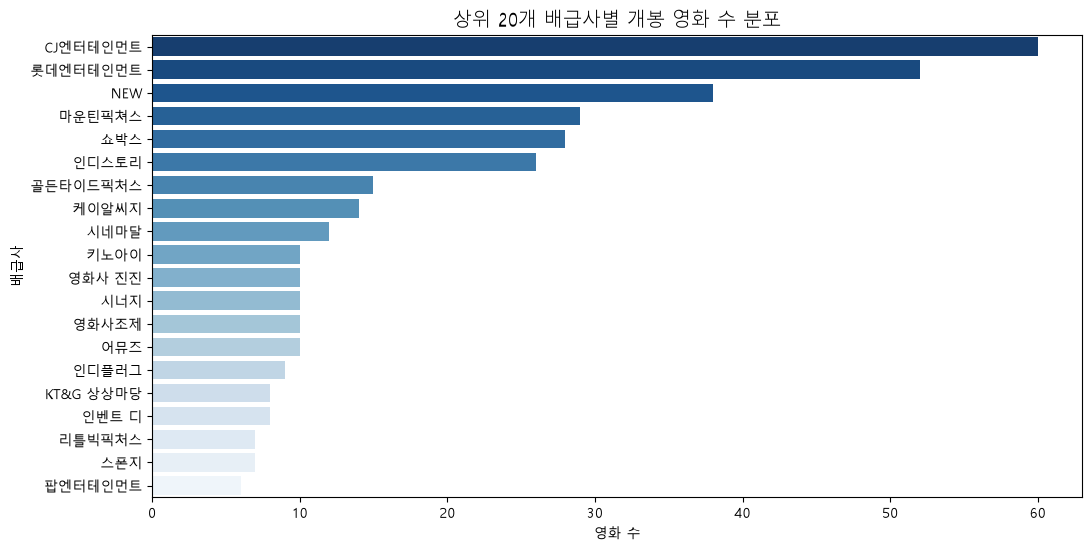

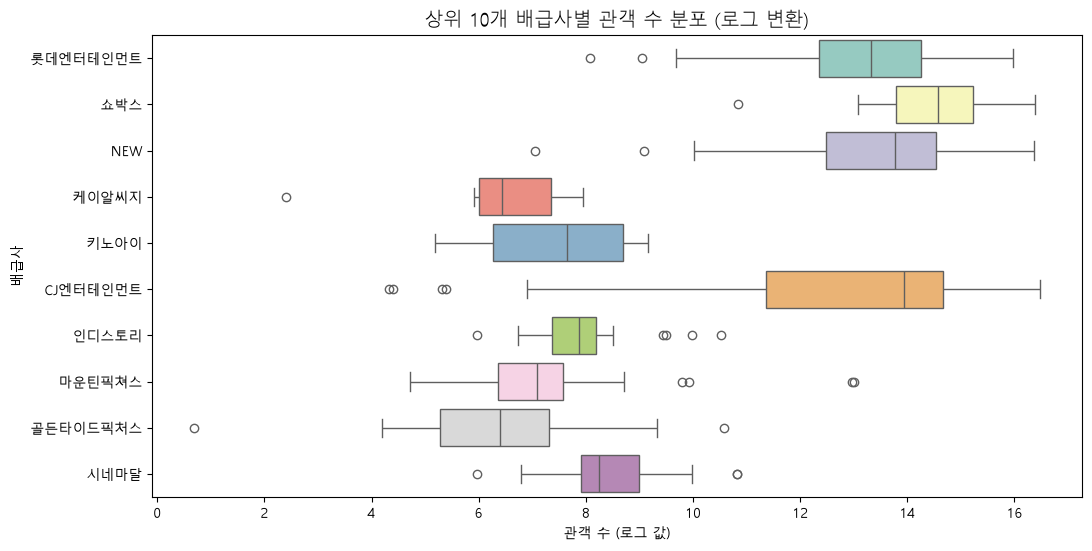

In [41]:
# 1. 전체 배급사 개수 출력
total_dist_count = train_df['distributor_clean'].nunique()
print(f"전체 배급사 수: {total_dist_count}개")

# 2. 상위 20개 배급사의 영화 수 분포 시각화
plt.figure(figsize=(12, 6))
top_20_dist = train_df['distributor_clean'].value_counts().head(20)

# y축 변수를 hue로 똑같이 지정하고 legend=False 추가
sns.barplot(
    x=top_20_dist.values, 
    y=top_20_dist.index, 
    hue=top_20_dist.index, 
    palette='Blues_r', 
    legend=False
)
plt.title('상위 20개 배급사별 개봉 영화 수 분포', fontsize=14)
plt.xlabel('영화 수')
plt.ylabel('배급사')
plt.show()

# 3. 상위 10개 배급사의 관객 수 분포 (박스플롯)
top_10_names = train_df['distributor_clean'].value_counts().head(10).index
top_10_df = train_df[train_df['distributor_clean'].isin(top_10_names)]

plt.figure(figsize=(12, 6))
# 마찬가지로 hue와 legend=False 추가
sns.boxplot(
    data=top_10_df, 
    x='log_box_off_num', 
    y='distributor_clean', 
    hue='distributor_clean', 
    palette='Set3', 
    legend=False
)
plt.title('상위 10개 배급사별 관객 수 분포 (로그 변환)', fontsize=14)
plt.xlabel('관객 수 (로그 값)')
plt.ylabel('배급사')
plt.show()

개봉 영화수 분포의 상위 6개 배급사에서 관객 수가 압도적으로 높은 4개의 배급사(롯데엔터테인먼트, 쇼박스, NEW, CJ엔터테인먼트)를 하나의 대형 그룹으로 묶는 것이 좋다고 판단

## **대형 배급사와 중소배급사를 그룹화**

In [26]:
# 대형 배급사와 독립/중소 배급사 구분 컬럼 생성
major_dists = ['CJ엔터테인먼트', '롯데엔터테인먼트', '쇼박스', 'NEW']
train_df['dist_type'] = train_df['distributor_clean'].apply(lambda x: '대형 배급사' if x in major_dists else '중소/독립 배급사')

## **[장르 및 관람등급 전처리 요소 확인]**

-불필요한 공백 등 없으므로 전처리할 필요 없음을 확인함 

In [27]:
# 장르 및 관람등급 종류 확인
print(train_df['genre'].unique())
print(train_df['screening_rat'].unique())

<ArrowStringArray>
[    '액션',    '느와르',    '코미디',  '다큐멘터리',    '뮤지컬',    '드라마', '멜로/로맨스',
     '공포',   '서스펜스',  '애니메이션',   '미스터리',     'SF']
Length: 12, dtype: str
<ArrowStringArray>
['청소년 관람불가', '15세 관람가', '전체 관람가', '12세 관람가']
Length: 4, dtype: str


# **3.EDA:관객 수와의 관계 파악하기**

## **[타겟 변수(관객 수) 분포 확인]**

원본 관객 수 분포 : right skewness를 확인함. 데이터가 몰려있어 통계분석과 시각화가 거의 불가능한 수준
로그 변환 관객 수 분포 : 쌍봉 분포(bimodal distribution) 형태 확인. 로그를 취함으로써 데이터 폭이 정돈되고 값의 범위가 고르게 확산. 관객 수에 따라 크게 두 그룹으로 나눌 수 있음을 확인 


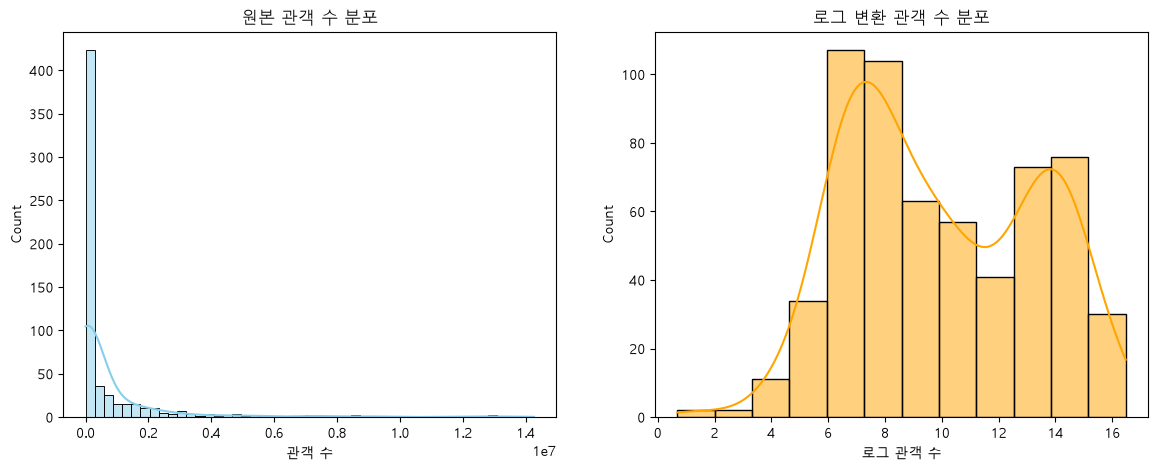

In [28]:
# 관객 수 분포 및 로그 변환 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df['box_off_num'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('원본 관객 수 분포')
axes[0].set_xlabel('관객 수')

sns.histplot(train_df['log_box_off_num'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('로그 변환 관객 수 분포')
axes[1].set_xlabel('로그 관객 수')

plt.show()

## **[수치형 변수와 관객 수의 관계]**

-스캐터플롯과 상관계수 히트맵 : 수치형변수들 간의 상관계수를 알아보고, 의미있는 상관을 가진 수치형변수들과 관객 수의 산점도를 나타냄. 


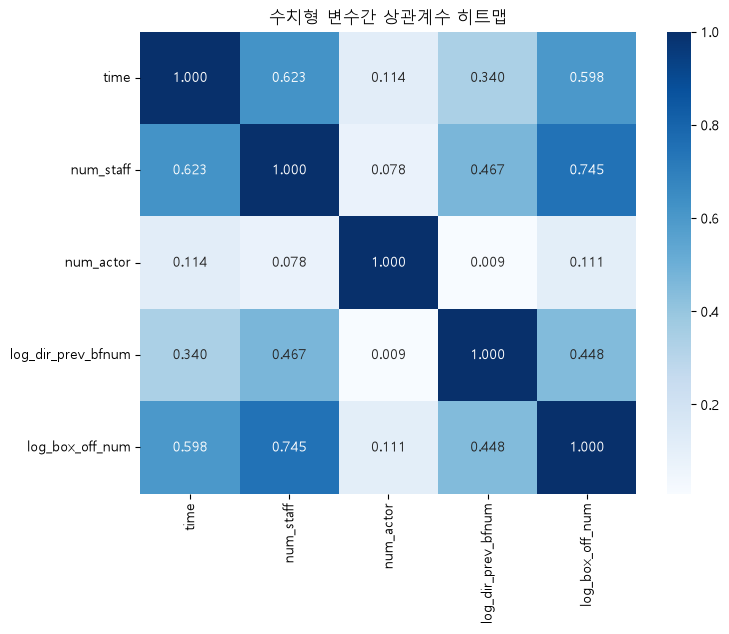

In [29]:
# 상관계수 히트맵
plt.figure(figsize=(8, 6))
num_cols = ['time', 'num_staff', 'num_actor', 'log_dir_prev_bfnum', 'log_box_off_num']
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap='Blues', fmt='.3f')
plt.title('수치형 변수간 상관계수 히트맵')
plt.show()

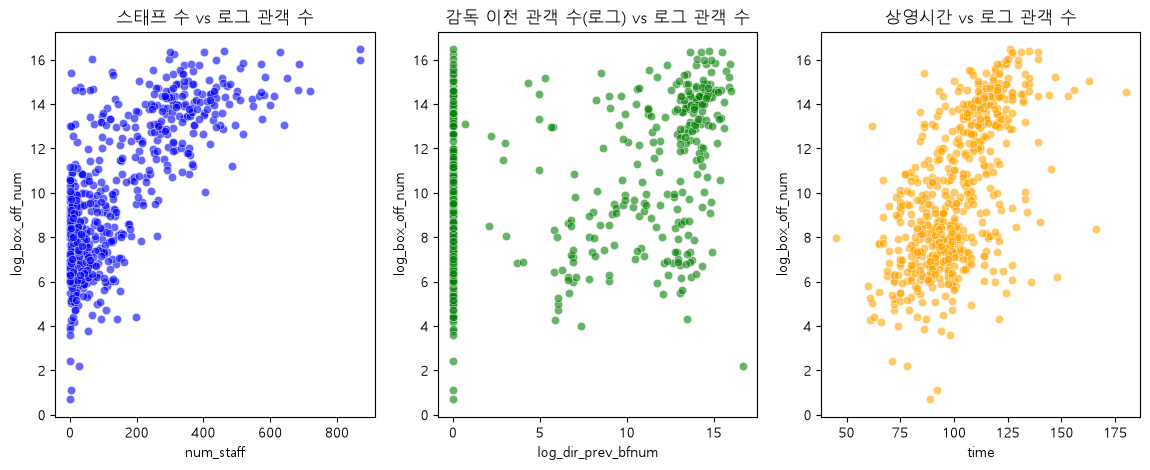

In [30]:
# 스태프 수 & 감독 이전 성적과 관객 수 관계
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.scatterplot(data=train_df, x='num_staff', y='log_box_off_num', alpha=0.6, ax=axes[0], color='blue')
axes[0].set_title('스태프 수 vs 로그 관객 수')

sns.scatterplot(data=train_df, x='log_dir_prev_bfnum', y='log_box_off_num', alpha=0.6, ax=axes[1], color='green')
axes[1].set_title('감독 이전 관객 수(로그) vs 로그 관객 수')

sns.scatterplot(data=train_df, x='time', y='log_box_off_num', alpha=0.6, ax=axes[2], color='orange')
axes[2].set_title('상영시간 vs 로그 관객 수')

plt.show()

감독의 전작 관객 수:

-이전에 dir_prev_bfnum의 결측치를 0으로 변환하였다. 즉 신임 감독을 포함하여 dir_prev_bfnum와 관객 수의 상관은 0.448이었다. 만약 신임 감독을 제외한 dir_prev_bfnum와 관객 수의 상관을 나타낸다면 0.409로 상관이 더 낮아짐.

[신인 감독 착시 효과 패러독스]
-전체 데이터 기준 상관계수(r=0.448)보다 신인 감독(결측치 0)을 제외한 경력 감독 대상 상관계수(r=0.409)가 더 낮게 나타났습니다.이는 신인 감독 집단이 '이전 성적 0 = 이번 관객 수 상대적 저조' 위치에 대량 몰려 있어 상관계수가 착시로 더 높게 측정되었음을 뜻합니다.

[전작 흥행이 차기작 흥행을 보장하지 않음]
-전작이 있는 감독 집단 내부만 분석했을 때 상관계수가 0.409로 낮아졌다는 것은 감독의 전작 흥행 성공이 차기작의 성공을 절대적으로 보장해주지는 않는다는 점을 보여줍니다. 따라서 관객 수 예측 시 감독의 이름값(전작 성적) 단독 변수보다는 배급사 체급, 스태프 수, 상영시간, 개봉 시즌 등의 복합적 요인을 함께 고려해야 함을 시사합니다.


In [31]:
# 감독 이전 성적이 0보다 큰(전작이 있는) 데이터만 필터링
experienced_dirs = train_df[train_df['dir_prev_bfnum'] > 0]

# 0을 제외한 상관계수 계산
corr_with_zero = train_df['log_dir_prev_bfnum'].corr(train_df['log_box_off_num'])
corr_without_zero = experienced_dirs['log_dir_prev_bfnum'].corr(experienced_dirs['log_box_off_num'])

print(f"0 포함 시 상관계수: {corr_with_zero:.3f}")
print(f"0 제외 시 상관계수: {corr_without_zero:.3f}")

0 포함 시 상관계수: 0.448
0 제외 시 상관계수: 0.409


상영시간&스태프 수 :상영시간이 긴 영화일수록 대규모 제작비 투입, 화려한 볼거리, 스태프 및 배우 규모가 큰 '대형 상업영화'일 가능성이 높기 때문에 관객수와의 상관이 높음, 또한 상영시간은 스태프수와도 상관이 높다. 

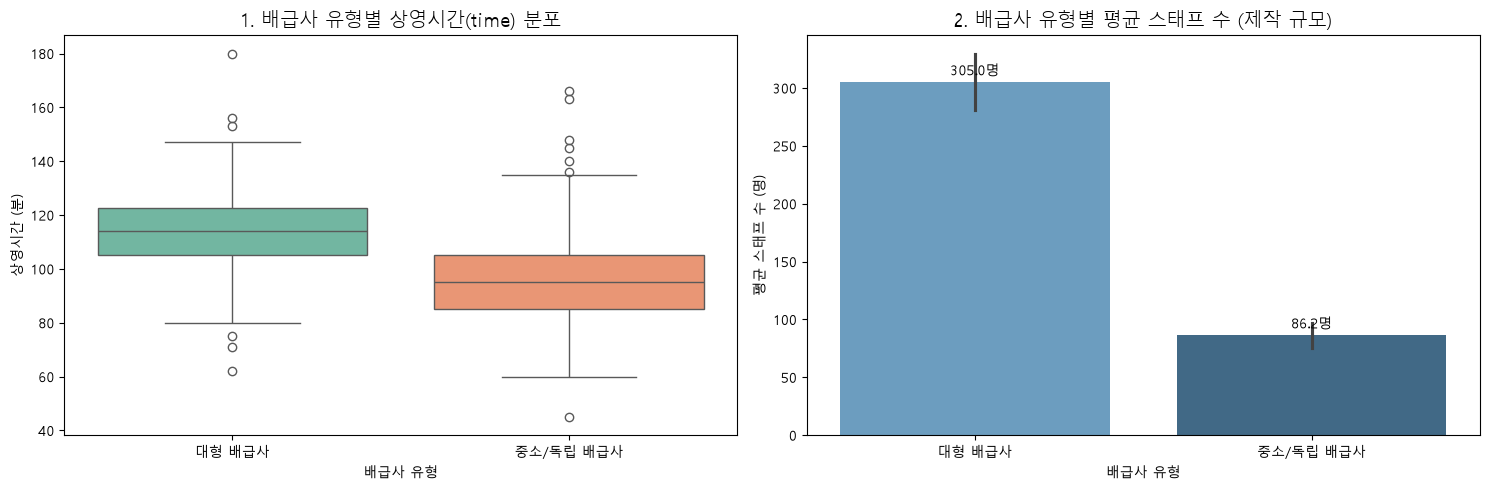

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. [왼쪽] 배급사 유형별 상영시간(time) 분포 (Boxplot)
sns.boxplot(
    data=train_df,
    x='dist_type',
    y='time',
    ax=axes[0],
    palette='Set2',
    hue='dist_type',
    legend=False,
)
axes[0].set_title(
    '1. 배급사 유형별 상영시간(time) 분포', fontsize=14
)
axes[0].set_xlabel('배급사 유형')
axes[0].set_ylabel('상영시간 (분)')

# 2. [오른쪽] 배급사 유형별 평균 스태프 수(num_staff) 비교 (Barplot)
sns.barplot(
    data=train_df,
    x='dist_type',
    y='num_staff',
    ax=axes[1],
    palette='Blues_d',
    hue='dist_type',
    legend=False,
)
axes[1].set_title(
    '2. 배급사 유형별 평균 스태프 수 (제작 규모)', fontsize=14
)
axes[1].set_xlabel('배급사 유형')
axes[1].set_ylabel('평균 스태프 수 (명)')

# 막대 상단에 스태프 수 수치 표시
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f'{height:.1f}명',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.tight_layout()
plt.show()

## **[날짜 파생 변수와 관객 수의 관계]**

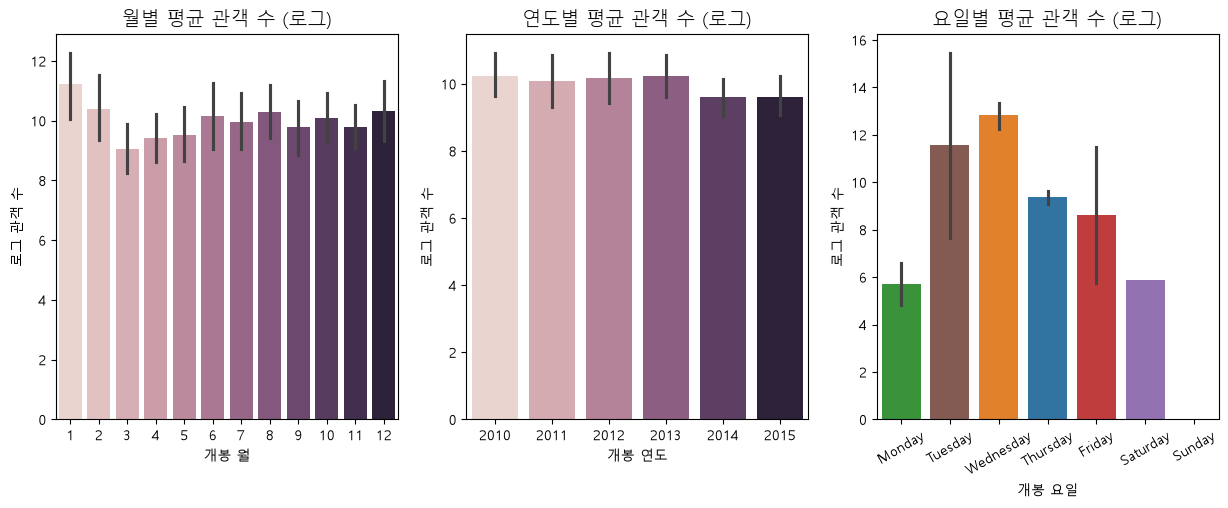

In [33]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 월별 평균 관객 수 (막대그래프)
sns.barplot(
    data=train_df, 
    x='release_month', 
    y='log_box_off_num', 
    ax=axes[0], 
    hue='release_month', 
    legend=False
)
axes[0].set_title('월별 평균 관객 수 (로그)', fontsize=14)
axes[0].set_xlabel('개봉 월')
axes[0].set_ylabel('로그 관객 수')

# 연도별 평균 관객 수 (막대그래프)
sns.barplot(
    data=train_df, 
    x='release_year', 
    y='log_box_off_num',  
    ax=axes[1], 
    hue='release_year', 
    legend=False
)
axes[1].set_title('연도별 평균 관객 수 (로그)', fontsize=14)
axes[1].set_xlabel('개봉 연도')
axes[1].set_ylabel('로그 관객 수')

# 요일별 평균 관객 수 (막대그래프)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(
    data=train_df,
    x='release_dayofweek', 
    y='log_box_off_num', 
    order=day_order, ax=axes[2], 
    hue='release_dayofweek', 
    legend=False)

axes[2].set_title('요일별 평균 관객 수 (로그)', fontsize=14)
axes[2].set_xlabel('개봉 요일')
axes[2].set_ylabel('로그 관객 수')
axes[2].tick_params(axis='x', rotation=30) # 글자 겹침 방지 기울임


plt.show()

개봉 연도: 특정 연도에 천만 관객 돌파 작품, 대형 흥행작이 몇 편 포함되었는지에 따라 해당 연도의 전체 평균 관객 수가 크게 영향받는 것으로 보임->유의미하지 않음

개봉 월과 개봉 요일이 유의미한 것으로 보이는데, 바플롯만으로 이상치를 확인하기 어려워 아래에 카운트플롯과 박스플롯을 추가함

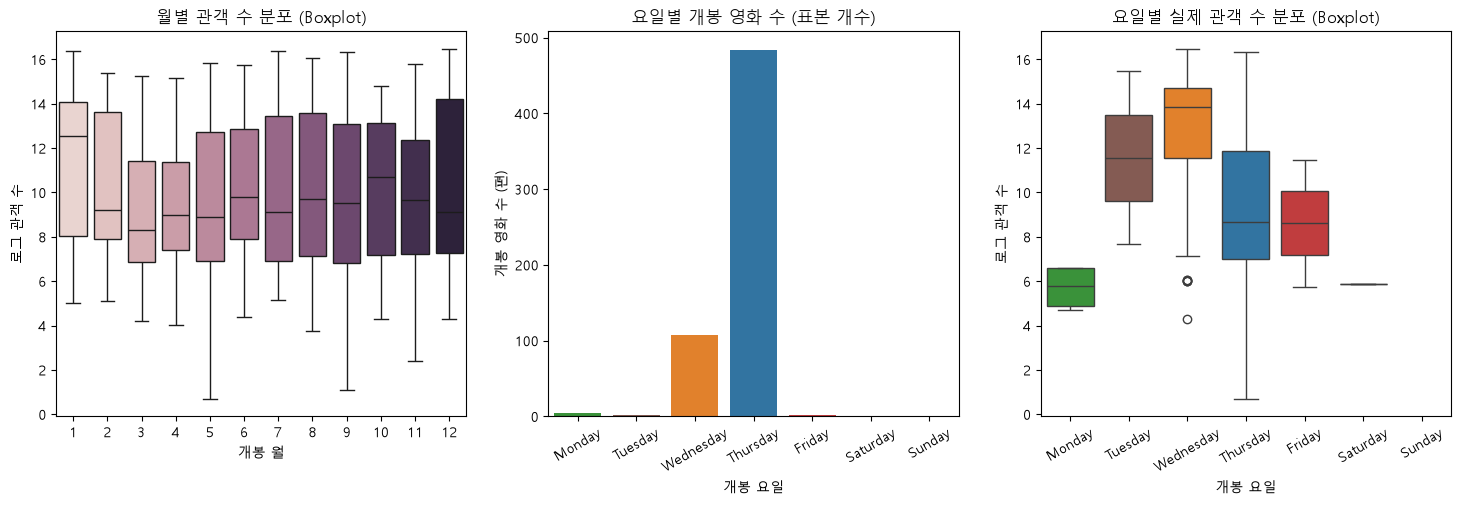

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 월별 관객 수 분포 (Boxplot: 중앙값 및 성수기 분포 확인)
sns.boxplot(data=train_df, x='release_month', y='log_box_off_num', ax=axes[0], hue='release_month', legend=False)
axes[0].set_title('월별 관객 수 분포 (Boxplot)')
axes[0].set_xlabel('개봉 월')
axes[0].set_ylabel('로그 관객 수')

# 요일별 개봉 영화 수 (Countplot: 화요일 표본 부족 증명)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=train_df, x='release_dayofweek', order=day_order, ax=axes[1], hue='release_dayofweek', legend=False)
axes[1].set_title('요일별 개봉 영화 수 (표본 개수)')
axes[1].set_xlabel('개봉 요일')
axes[1].set_ylabel('개봉 영화 수 (편)')
axes[1].tick_params(axis='x', rotation=30)

# 요일별 관객 수 분포 (Boxplot: 실질적 중앙값 체급 비교)
sns.boxplot(data=train_df, x='release_dayofweek', y='log_box_off_num', order=day_order, ax=axes[2], hue='release_dayofweek', legend=False)
axes[2].set_title('요일별 실제 관객 수 분포 (Boxplot)')
axes[2].set_xlabel('개봉 요일')
axes[2].set_ylabel('로그 관객 수')
axes[2].tick_params(axis='x', rotation=30)

plt.show()

개봉 월: 7, 8월과 12, 1월에 개봉한 영화들의 평균 관객 수가 다른 달에 비해 눈에 띄게 높게 형성 학생들의 방학, 직장인들의 휴가철, 연말연시 연휴 등 영화관 유입 인구 자체가 늘어나는 대목 시즌이며, 배급사들 또한 이 시기에 제작비가 큰 대형 상업영화(텐트폴 작품)를 집중적으로 배치하기 때문 / 봄/가을 비수기(3, 4월, 9, 10월) 상대적으로 관객 수가 낮게 형성되며, 주로 중소규모 영화나 다양성 영화가 개봉하는 경향

개봉 요일: 주말 관객 동원과 초반 기세 잡기를 위해 메이저 대형 영화들은 주로 수요일과 목요일에 개봉하므로 수/목요일 개봉작의 평균 관객 수 체급이 높게 형성되는 반면, 월/화요일 개봉작은 재개봉작이나 기획전, 소규모 독립영화 비중이 높아 평균 관객 수가 상대적으로 저조. 화요일은 개봉작이 몇 안되어 관객 수 변동성이 큰 것으로 확인됨

->영화의 흥행(관객 수)은 개봉 시점의 계절성(7~8월, 12월 성수기)과 요일별 개봉 전략(수/목요일 집중)에 유의미한 영향을 받음

## **[범주형 변수와 관객 수의 관계]**

## **배급사**

-위에서 로그 변환 관객 수 분포가 크게 두 그룹으로 나눠짐을 확인하고, 배급사와의 관계를 예상하여 그 분포를 확인하였더니 비슷하게 관객 수가 두 그룹으로 나뉘는 것을 확인할 수 있었음 

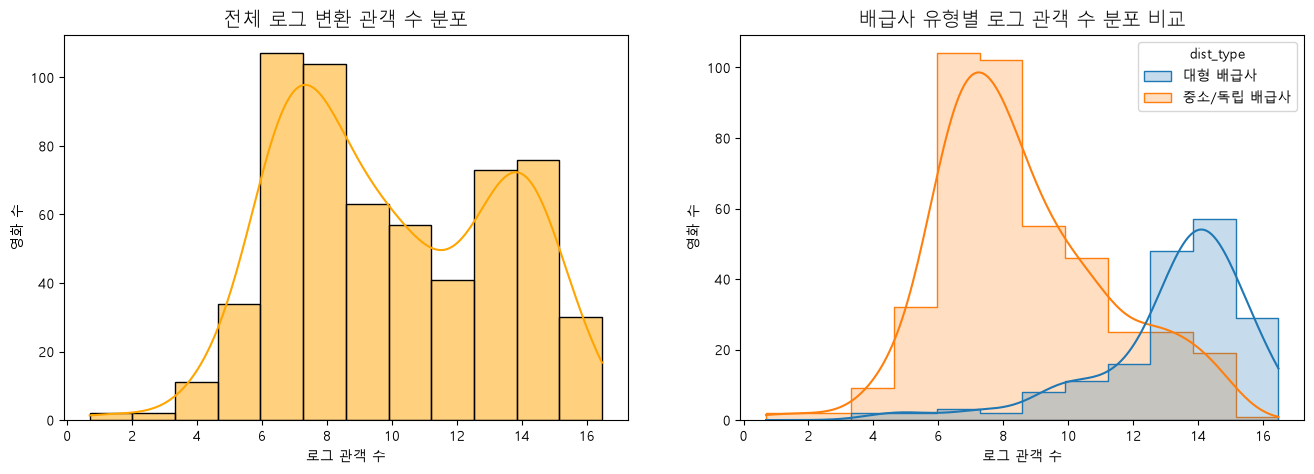

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=train_df, x='log_box_off_num', kde=True, ax=axes[0], color='orange'
)
axes[0].set_title('전체 로그 변환 관객 수 분포', fontsize=14)
axes[0].set_xlabel('로그 관객 수')
axes[0].set_ylabel('영화 수')


# 배급사 유형별 로그 관객 수 분포 시각화
sns.histplot(data=train_df, x='log_box_off_num', hue='dist_type', kde=True, element="step", ax=axes[1])
axes[1].set_title('배급사 유형별 로그 관객 수 분포 비교', fontsize=14)
axes[1].set_xlabel('로그 관객 수')
axes[1].set_ylabel('영화 수')

plt.show()

## **장르&관람등급&주연배우 수 그룹**


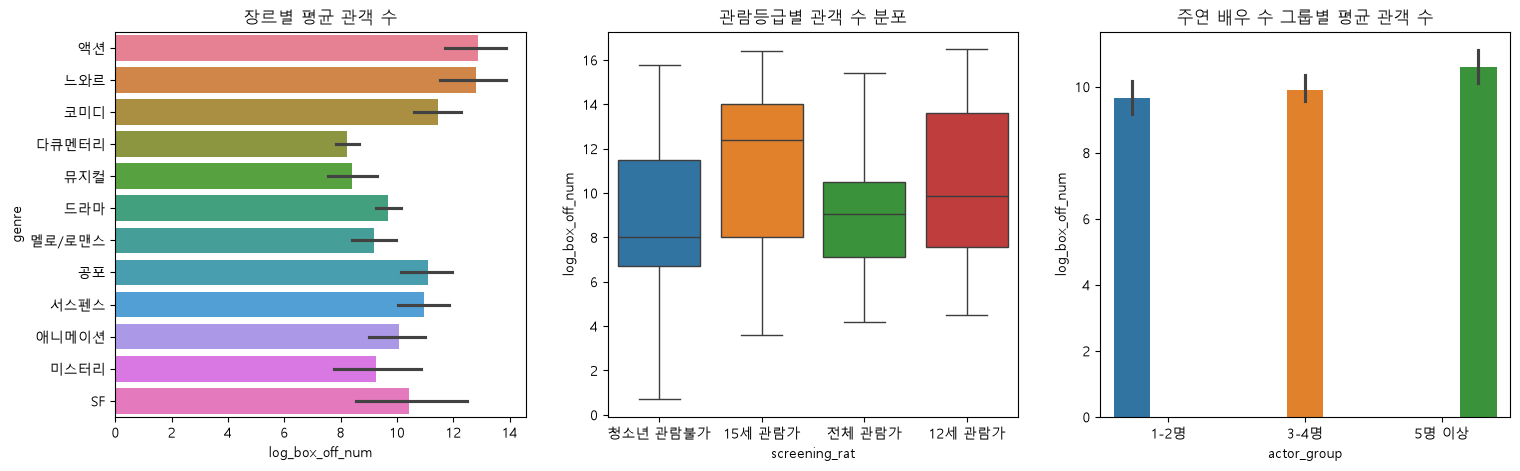

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 장르별 평균 관객 수
sns.barplot(data=train_df, x='log_box_off_num', y='genre', ax=axes[0], hue='genre', legend=False)
axes[0].set_title('장르별 평균 관객 수')

# 관람등급별 관객 수
sns.boxplot(data=train_df, x='screening_rat', y='log_box_off_num', ax=axes[1], hue='screening_rat', legend=False)
axes[1].set_title('관람등급별 관객 수 분포')

# 주연 배우 수 그룹별 관객 수
sns.barplot(data=train_df, x='actor_group', y='log_box_off_num', ax=axes[2], hue='actor_group', legend=False)
axes[2].set_title('주연 배우 수 그룹별 평균 관객 수')

plt.show()

장르: 느와르, 액션, 코미디 장르의 평균 로그 관객 수가 상위권을 차지함. (대형 자본과 유명 배우가 집중 배치되는 오락성 강한 상업영화 비중이 높아 평균 흥행 실적이 우수, 다큐멘터리/뮤지컬 등 장르는 중소/독립 배급사 비중이 높기 때문)

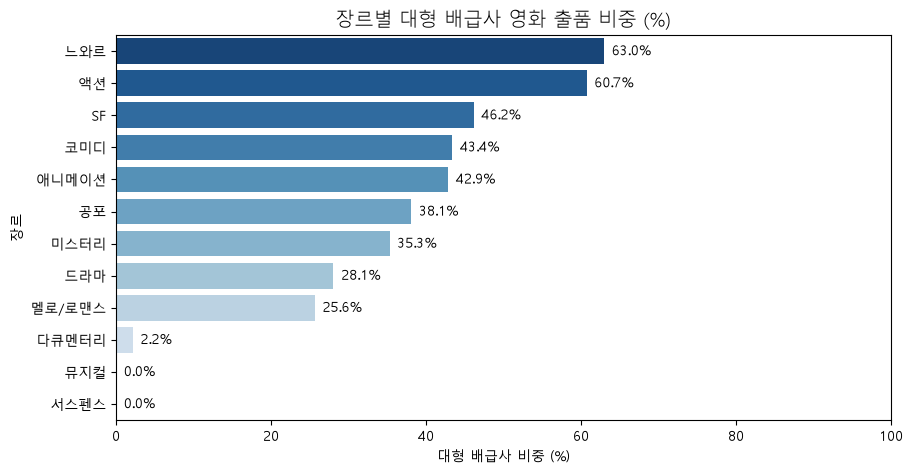

In [37]:
# 장르별 대형 배급사(dist_type == '대형 배급사') 비율 계산
major_ratio = train_df.groupby('genre')['dist_type'].apply(lambda x: (x == '대형 배급사').mean() * 100).reset_index()
major_ratio.rename(columns={'dist_type': 'major_ratio'}, inplace=True)

# 비율 높은 순으로 정렬
major_ratio = major_ratio.sort_values(by='major_ratio', ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=major_ratio, x='major_ratio', y='genre', palette='Blues_r', hue='genre', legend=False)
plt.title('장르별 대형 배급사 영화 출품 비중 (%)', fontsize=14)
plt.xlabel('대형 배급사 비중 (%)')
plt.ylabel('장르')

# 막대 끝에 퍼센트 수치 표시
for index, row in major_ratio.reset_index(drop=True).iterrows():
    plt.text(row['major_ratio'] + 1, index, f"{row['major_ratio']:.1f}%", va='center')

plt.xlim(0, 100)

plt.show()

관람등급: 
-15세 관람가와 12세 관람가: 중앙값(박스 중앙선) 및 상단 분포가 높고 안정적(친구, 연인, 가족 단위 관객을 넓게 수용할 수 있어 대형 상업영화들이 가장 선호하는 등급), 
-전체 관람가: 어린이/가족 영화나 저예산 애니메이션/다큐멘터리가 많이 포함되어 평균 체급 및 분포가 상대적으로 낮게 형성, 
-청소년 관람불가: 관객층 유입 제한으로 인해 변동성(박스 범위)이 크며, 대작 흥행작과 소규모 잔혹/성인 영화 간의 격차가 크게 나타남

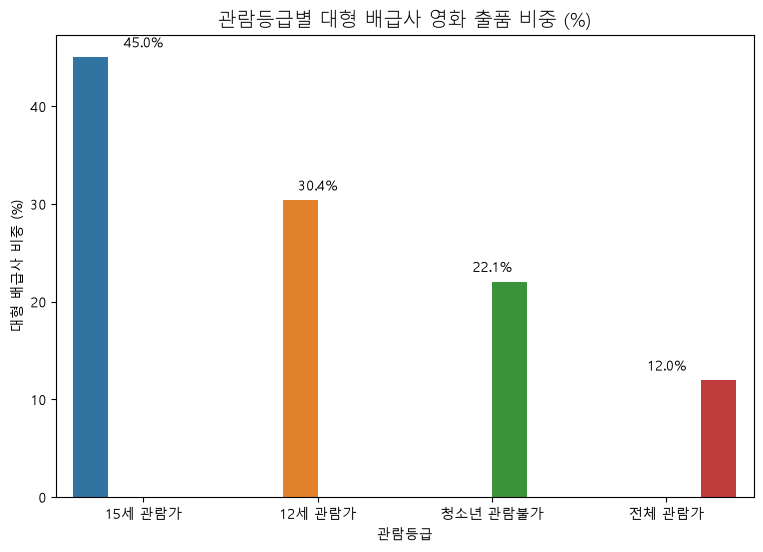

In [38]:
#12/15세 관람가에 대한 시각화 

# 1. 관람등급별 대형 배급사(dist_type == '대형 배급사') 비율 계산
rat_major_ratio = train_df.groupby('screening_rat')['dist_type'].apply(lambda x: (x == '대형 배급사').mean() * 100).reset_index()
rat_major_ratio.rename(columns={'dist_type': 'major_ratio'}, inplace=True)

# 보기 편하게 정렬 (15세 -> 12세 -> 청불 -> 전체 순)
rat_order = ['15세 관람가', '12세 관람가', '청소년 관람불가', '전체 관람가']
rat_major_ratio['screening_rat'] = pd.Categorical(rat_major_ratio['screening_rat'], categories=rat_order, ordered=True)
rat_major_ratio = rat_major_ratio.sort_values('screening_rat')

# 2. 시각화
plt.figure(figsize=(9, 6))
sns.barplot(data=rat_major_ratio, x='screening_rat', y='major_ratio', hue='screening_rat', legend=False)
plt.title('관람등급별 대형 배급사 영화 출품 비중 (%)', fontsize=14)
plt.xlabel('관람등급')
plt.ylabel('대형 배급사 비중 (%)')

# 막대 상단에 퍼센트 수치 표시
for index, row in rat_major_ratio.reset_index(drop=True).iterrows():
    plt.text(index, row['major_ratio'] + 1, f"{row['major_ratio']:.1f}%", ha='center')



plt.show()

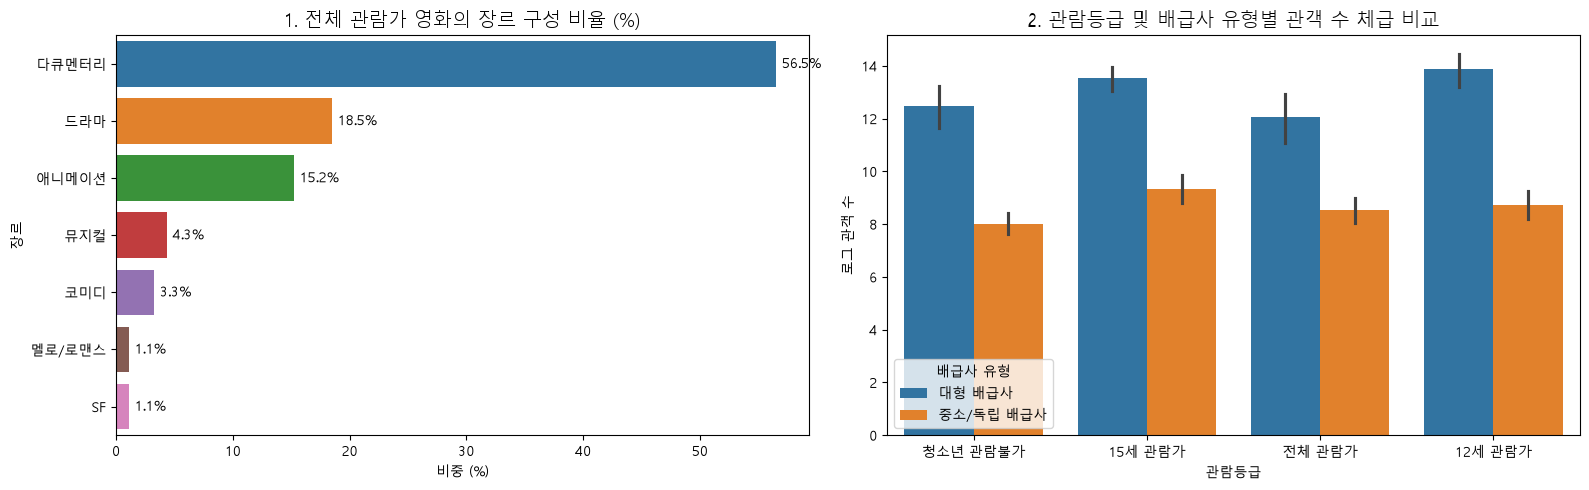

In [39]:
# 전체 관람가에 대한 시각화 

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. [왼쪽] 전체 관람가 내부 장르 구성 비중 (%)
# 전체 관람가 영화들만 추출하여 어떤 장르가 많은지 확인
all_rat_df = train_df[train_df['screening_rat'] == '전체 관람가']
genre_counts = all_rat_df['genre'].value_counts(normalize=True) * 100

sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0], hue=genre_counts.index, legend=False)
axes[0].set_title('1. 전체 관람가 영화의 장르 구성 비율 (%)', fontsize=14)
axes[0].set_xlabel('비중 (%)')
axes[0].set_ylabel('장르')

# 막대 끝에 퍼센트 표시
for index, value in enumerate(genre_counts.values):
    axes[0].text(value + 0.5, index, f'{value:.1f}%', va='center')

# 2. [오른쪽] 관람등급 x 배급사 유형별 평균 관객 수 체급 비교
# 대형 배급사와 중소/독립 배급사 간 관객 수 격차 시각화
sns.barplot(data=train_df, x='screening_rat', y='log_box_off_num', hue='dist_type', ax=axes[1])
axes[1].set_title('2. 관람등급 및 배급사 유형별 관객 수 체급 비교', fontsize=14)
axes[1].set_xlabel('관람등급')
axes[1].set_ylabel('로그 관객 수')
axes[1].legend(title='배급사 유형')

plt.tight_layout()
plt.show()

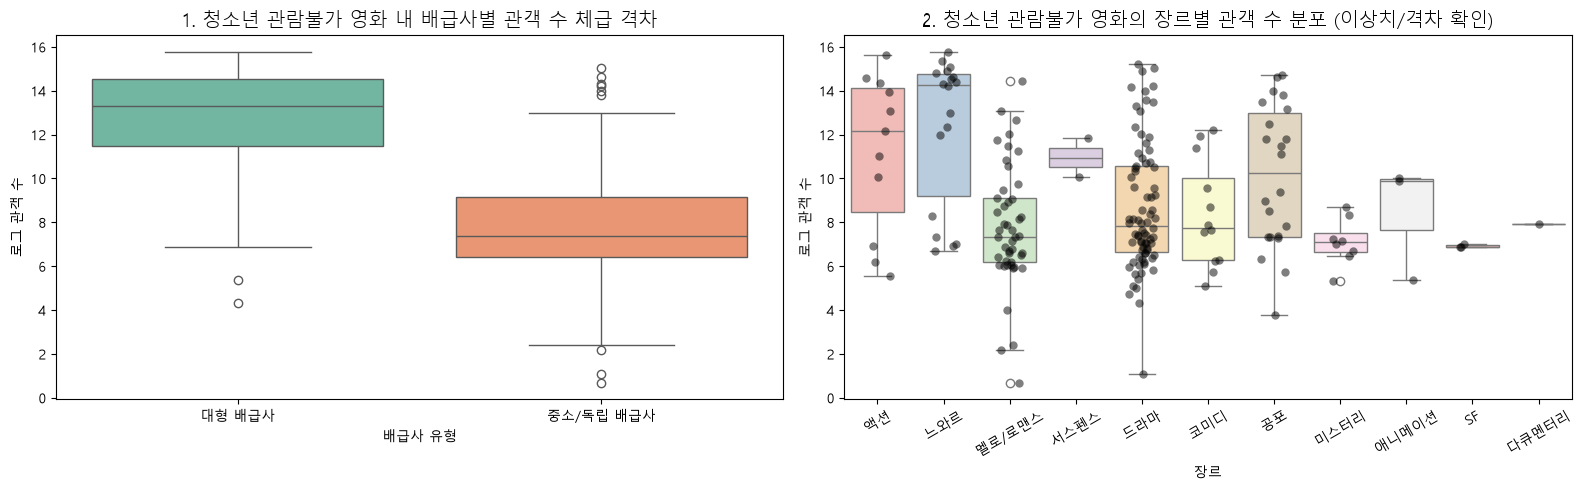

In [40]:
#청소년 관람불가에 대한 시각화 

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. 청소년 관람불가 영화 내 '배급사 유형별' 관객 수 분포 (Boxplot)
youth_df = train_df[train_df['screening_rat'] == '청소년 관람불가']

sns.boxplot(
    data=youth_df,
    x='dist_type',
    y='log_box_off_num',
    ax=axes[0],
    palette='Set2',
    hue='dist_type',
    legend=False,
)
axes[0].set_title(
    '1. 청소년 관람불가 영화 내 배급사별 관객 수 체급 격차', fontsize=14
)
axes[0].set_xlabel('배급사 유형')
axes[0].set_ylabel('로그 관객 수')

# 2. 청소년 관람불가 영화 내 장르별 관객 수 분포 (산점도 + 박스플롯)
sns.stripplot(
    data=youth_df,
    x='genre',
    y='log_box_off_num',
    ax=axes[1],
    size=6,
    jitter=0.2,
    color='black',
    alpha=0.5,
)
sns.boxplot(
    data=youth_df,
    x='genre',
    y='log_box_off_num',
    ax=axes[1],
    palette='Pastel1',
    hue='genre',
    legend=False,
)
axes[1].set_title(
    '2. 청소년 관람불가 영화의 장르별 관객 수 분포 (이상치/격차 확인)',
    fontsize=14,
)
axes[1].set_xlabel('장르')
axes[1].set_ylabel('로그 관객 수')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

주연배우 수 그룹: 주연배수 수가 증가할수록 평균 관객 수가 상승하는 경향. (등장인물과 멀티캐스팅 요소가 늘어날수록 제작비가 높은 대형 상업영향일 확률이 높아서)

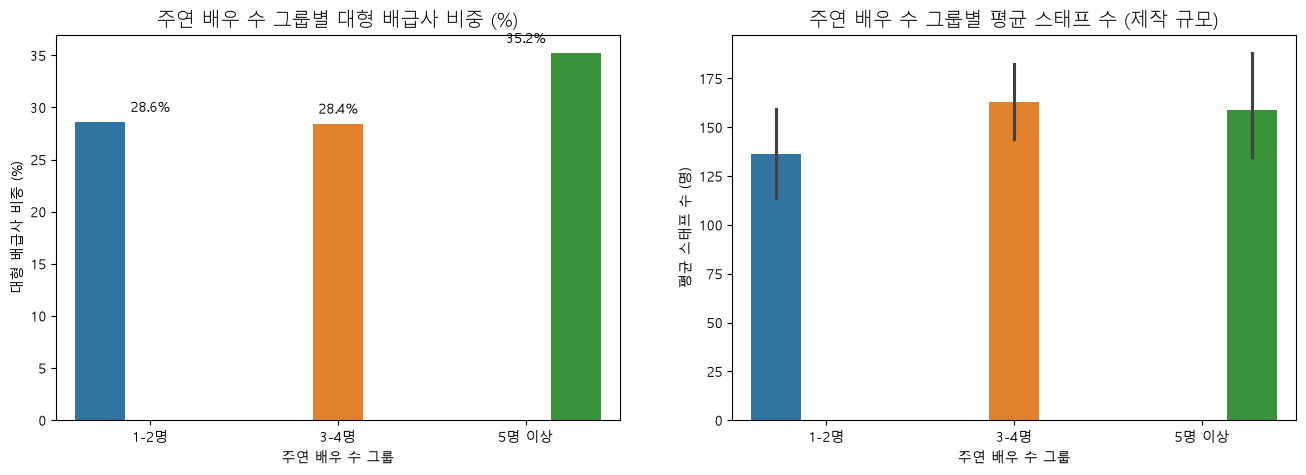

In [186]:
#주연 배우 수와 대형 상업영화 확률 간의 원인 입증 시각화

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. [왼쪽] 주연 배우 수 그룹별 '대형 배급사' 출품 비중 (%)
# 배우 수가 많을수록 대형 배급사(상업영화) 비율이 높아짐을 증명
actor_major_ratio = train_df.groupby('actor_group')['dist_type'].apply(lambda x: (x == '대형 배급사').mean() * 100).reset_index()
actor_major_ratio.rename(columns={'dist_type': 'major_ratio'}, inplace=True)

sns.barplot(data=actor_major_ratio, x='actor_group', y='major_ratio', ax=axes[0], hue='actor_group', legend=False)
axes[0].set_title('주연 배우 수 그룹별 대형 배급사 비중 (%)', fontsize=14)
axes[0].set_xlabel('주연 배우 수 그룹')
axes[0].set_ylabel('대형 배급사 비중 (%)')

# 막대 상단에 퍼센트 표시
for index, row in actor_major_ratio.reset_index(drop=True).iterrows():
    axes[0].text(index, row['major_ratio'] + 1, f"{row['major_ratio']:.1f}%", ha='center')

# 2. [오른쪽] 주연 배우 수 그룹별 '평균 스태프 수' (제작 규모 간접 지표)
# 배우 수가 많을수록 스태프 수도 많아져 제작비 규모가 큼을 입증
sns.barplot(data=train_df, x='actor_group', y='num_staff', ax=axes[1], hue='actor_group', legend=False)
axes[1].set_title('주연 배우 수 그룹별 평균 스태프 수 (제작 규모)', fontsize=14)
axes[1].set_xlabel('주연 배우 수 그룹')
axes[1].set_ylabel('평균 스태프 수 (명)')

plt.show()